# P3: Greedy Best-First Search

**FIT1061 Introduction to Artificial Intelligence — Week 3**

BFS finds the shortest path — but it explores everywhere. What if we had a *sense of direction*? Greedy best-first search uses a **heuristic** to guess which cells are closest to the goal and explores those first. In 2016, AlphaGo's Move 37 stunned the world — a move no human would play, found by an algorithm with a sense of direction.

**This notebook covers P3.1 (personalised hand trace), P3.2 (distance functions), and P3.3 (greedy best-first search).** P3.1 is personalised by your Monash student ID — see the 'Your personalised instance' section below.

**Pre-reading:** If you haven't already, read `P3_preread_priority_queues.md` to understand what a priority queue is and why greedy best-first search needs one.

> **🗣 Milestone task.** P3 requires a tutor discussion for sign-off. After completing all parts (including the hand trace and reflection), book a discussion with your tutor.

---

## Setup

Run the cell below to import the helper classes. These are defined in `p3_helpers.py` (in the same folder as this notebook). **You do not need to modify `p3_helpers.py`.**

In [15]:
from p3_helpers import (PriorityQueue, Queue, GridWorld, reconstruct_path,
                        HAND_TRACE_GRAPH, HEURISTIC_TO_G,
                        draw_hand_trace_graph_with_heuristics)
import math
print("Imports OK.")

Imports OK.


---

## Warm-up: a greedy trace

In the lecture you saw **greedy best-first search** return a longer path than the true shortest.
Here is a small graph in the same spirit (not the identical one from the slides) — work the greedy
trace yourself to warm up, then trace greedy on your own graph in Part 0.

Stuck? Revisit the greedy trace in the slides or the workshop — the idea is identical, only the graph differs.

**The graph (undirected):**

```
S – {A, B}     A – {S, G}     B – {S, C, D}
C – {B}     D – {B, E}     E – {D, G}     G – {A, E}
```

**Heuristic h (straight-line estimate of distance to G):** S=6, A=6, B=2, C=4, D=2, E=1, G=0.

Greedy always expands the frontier node with the **lowest h**. Run it from **S** to **G**. The
first step is done for you:

| Step | Expand (lowest h) | Frontier after (node, h) | Visited after |
|---|---|---|---|
| 1 | S | (B,2), (A,6) | {S} |
| 2 | ? | ? | ? |
| ... | | | |

1. What path does greedy return from S to G?
2. What is the **true shortest** path (fewest edges)? Why didn't greedy find it?

*(Same trace as Part 0 below: there you run greedy on YOUR own heuristic.)*


---

## Your personalised instance (P3.1)

Greedy best-first search is **personalised** for this task. Each student gets a different heuristic over the same 7-node graph. Your hand trace and reflection must use YOUR instance.

**Set your Monash student ID below**, then run the next two cells. Do not edit `task_instances.py`.


In [16]:
# Replace the placeholder with your Monash student ID (8 digits).
STUDENT_ID = "37524720"

assert STUDENT_ID.isdigit() and len(STUDENT_ID) == 8, (
    "Set STUDENT_ID to your 8-digit Monash student ID (digits only, in quotes)."
)


In [17]:
# Integrity check + instance generation.
# DO NOT EDIT task_instances.py — your tutor regenerates from your ID
# and compares fingerprints. Modifications will be caught.

from task_instances import generate_instance
from task_instances_lib import fingerprint

instance = generate_instance(STUDENT_ID)
trace = instance["trace"]

print(f"Student ID:                {STUDENT_ID}")
print(f"task_instances.py SHA-256: {fingerprint('task_instances.py')}")


Student ID:                37524720
task_instances.py SHA-256: 35b8c2a4196264ecb6b9798ca4a08c792c6d616bacf4eff50a2c60f155e25927


---

## Part 0: The hand-trace graph (P3.1)

You were given a personalised graph above (the **Your personalised instance** section). Run the cell below to render YOUR graph with YOUR heuristic values.

Notice the yellow labels: `h=6` means "this node is *estimated* to be 6 steps from the goal." Greedy best-first search always expands the node with the **lowest h-value** in the frontier.

**Before continuing**, hand-trace greedy best-first search on YOUR graph step by step:

1. At each step, record the **current node** popped from the frontier.
2. List the **frontier contents** (with priorities) after pushing neighbours.
3. List the **visited set** after this step.

Photograph your hand trace: this is the P3.1 deliverable.

> **Different students get different heuristics.** Your trace will look different from a peer's. Tutors regenerate from your Monash ID to verify.


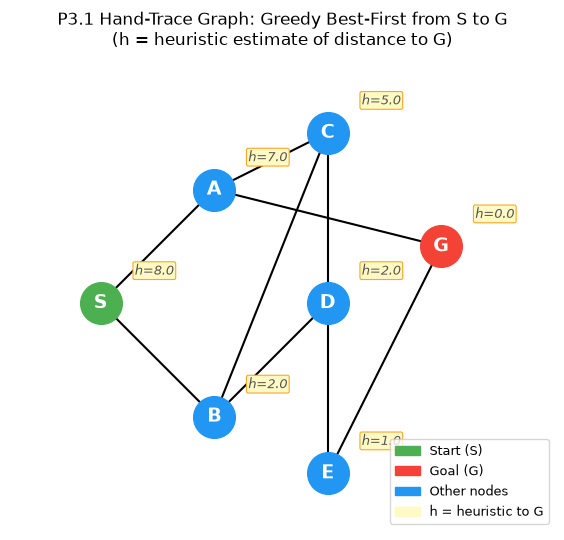

Your graph adjacency list:
  S -> ['A', 'B']
  A -> ['C', 'G', 'S']
  B -> ['C', 'D', 'S']
  C -> ['A', 'B', 'D']
  D -> ['B', 'C', 'E']
  E -> ['D', 'G']
  G -> ['A', 'E']

Your heuristic values (estimated distance to G):
  h(A) = 7.0
  h(B) = 2.0
  h(C) = 5.0
  h(D) = 2.0
  h(E) = 1.0
  h(G) = 0.0
  h(S) = 8.0


In [18]:
draw_hand_trace_graph_with_heuristics(graph=trace.graph, heuristic=trace.heuristic)

print("Your graph adjacency list:")
for node, neighbours in trace.graph.items():
    print(f"  {node} -> {neighbours}")

print("\nYour heuristic values (estimated distance to G):")
for node, h in trace.heuristic.items():
    print(f"  h({node}) = {h}")


---

### Articulation (P3.1: graded with the photo)

Answer these about YOUR instance. Numbers will differ from a peer's, so generic AI-written answers will not match.

1. What is `h(C)` for your instance?
2. From `S`, which node does greedy expand **first**? Why? (Compare `h(S)`, `h(A)`, `h(B)`.)
3. From `B`, which node does greedy expand next? Why?
4. Did greedy expand `C` in your trace? (Hint: depends on whether `h(C) < h(D)` after `B` is popped.)
5. What path did greedy return? How many edges long?
6. Did greedy find the **shortest** path from `S` to `G`? If not, what shorter path was there, and why did greedy miss it?

Write your answers in the cell below, then photograph your hand trace and answers together for the P3.1 submission.


In [19]:
# Articulation answers — type your responses here.
# Reference YOUR h-values printed above. Be specific.

answers = {
    "h_C": 13,                    # numeric, e.g. 3.0
    "first_expanded_after_S": 'B', # "A" or "B"
    "second_expanded_after_S": 'D',# the node greedy picks from B's neighbours
    "expanded_C": False,             # True or False
    "path": ["S","B", "D","E","G"],                   # list, e.g. ["S", "B", "D", "E", "G"]
    "found_shortest": False,         # True or False
}

# Brief explanation (2-3 sentences) — why greedy made the choices it did,
# referencing your h-values:
explanation = """
greedy search follows the weight you give, so it found the route with lowst weight, but not in the least nodes
"""

# Sanity checks (only verify the cell is filled, not correctness).
for k, v in answers.items():
    assert v is not None, f"answers['{k}'] is still None"
assert explanation.strip() != "TYPE YOUR EXPLANATION HERE.", "Write your explanation."
print("Filled in. Photograph hand trace + this cell for P3.1.")


Filled in. Photograph hand trace + this cell for P3.1.


---

## Part 1: Explore the priority queue

In P2, BFS used a **Queue** (FIFO: first in, first out). Greedy best-first search uses a **PriorityQueue**: items come out in order of their priority (lowest first), regardless of when they were added.

Run the cell below to see how it works.

In [20]:
pq = PriorityQueue()
print(f"Empty? {pq.is_empty()}")  # True

pq.push("far away", priority=10)
pq.push("very close", priority=2)
pq.push("medium", priority=5)
print(f"\nAfter pushing three items: {pq}")

first = pq.pop()
print(f"\nPopped: {first}")  # Should be "very close" (priority=2, lowest)
second = pq.pop()
print(f"Popped: {second}")  # Should be "medium" (priority=5)
print(f"Remaining: {pq}")

Empty? True

After pushing three items: PriorityQueue([(2, 'very close'), (5, 'medium'), (10, 'far away')])

Popped: very close
Popped: medium
Remaining: PriorityQueue([(10, 'far away')])


**Checkpoint:** The cell above should show that `pop()` returns `"very close"` first: the item with the **lowest** priority number (2). This is different from a regular queue, where items come out in the order they were added.

**Key insight:** In greedy best-first search, the priority is the *heuristic distance to the goal*. So the node that appears closest to the goal is always expanded first.

---

## Part 2: Implement distance functions (P3.2)

Before we can search with a heuristic, we need a way to estimate how far a cell is from the goal. You'll implement two common distance functions.

Both functions take two arguments, `a` and `b`, which are **grid positions**: `(row, col)` tuples. For example, `a = (1, 0)` means row 1, column 0.

**Manhattan distance** (city-block distance): the distance if you can only move along grid lines (horizontal + vertical steps):
$$d(a, b) = |a_{\text{row}} - b_{\text{row}}| + |a_{\text{col}} - b_{\text{col}}|$$

**Euclidean distance** (straight-line distance): the "as the crow flies" distance:
$$d(a, b) = \sqrt{(a_{\text{row}} - b_{\text{row}})^2 + (a_{\text{col}} - b_{\text{col}})^2}$$

**Example:** From `a = (1, 0)` to `b = (4, 4)`:

```
     0   1   2   3   4
   ┌───┬───┬───┬───┬───┐
 0 │   │   │   │   │   │
   ├───┼───┼───┼───┼───┤
 1 │ a │ → │ → │ → │ → │  Manhattan: 3 + 4 = 7
   ├───┼───┼───┼───┼───┤     (3 rows down + 4 columns right)
 2 │   │   │   │   │ ↓ │
   ├───┼───┼───┼───┼───┤  Euclidean: √(3² + 4²) = 5.0
 3 │   │   │   │   │ ↓ │     (straight line, the 3-4-5 triangle)
   ├───┼───┼───┼───┼───┤
 4 │   │   │   │   │ b │
   └───┴───┴───┴───┴───┘
              ╲
               ╲  Euclidean = 5.0
                ╲  (straight line)
```

Manhattan distance is always ≥ Euclidean distance. On our grid (where you can only move up/down/left/right), Manhattan distance matches the actual minimum number of steps.

In [21]:
def manhattan_distance(a, b):
    """Return Manhattan distance between positions a and b.

    Args:
        a: (row, col) tuple — a position on the grid.
        b: (row, col) tuple — another position on the grid.

    Returns:
        The Manhattan distance (an integer).
    """
    # --- YOUR CODE HERE ---
    result=abs(a[0]-b[0])+abs(a[1]-b[1])

    pass  # Remove this line


def euclidean_distance(a, b):
    """Return Euclidean distance between positions a and b.

    Args:
        a: (row, col) tuple — a position on the grid.
        b: (row, col) tuple — another position on the grid.

    Returns:
        The Euclidean distance (a float).
    """
    # --- YOUR CODE HERE ---
    result=math.sqrt(math.pow(a[0]-b[0], 2)+math.pow(a[1]-b[1], 2))
    return result
    pass  # Remove this line

### Test your distance functions

Run the cell below to check your implementations. All tests should pass.

In [22]:
# Unit tests for distance functions
def test_distances():
    passed = 0
    failed = 0

    # Manhattan distance tests
    tests_manhattan = [
        ((0, 0), (0, 0), 0, "same point"),
        ((0, 0), (3, 4), 7, "(0,0) to (3,4)"),
        ((1, 2), (4, 6), 7, "(1,2) to (4,6)"),
        ((5, 5), (0, 0), 10, "(5,5) to (0,0)"),
        ((0, 0), (0, 5), 5, "horizontal only"),
        ((0, 0), (5, 0), 5, "vertical only"),
    ]

    print("Manhattan distance tests:")
    for a, b, expected, label in tests_manhattan:
        result = manhattan_distance(a, b)
        if result == expected:
            print(f"  PASS: {label} -> {result}")
            passed += 1
        else:
            print(f"  FAIL: {label} -> got {result}, expected {expected}")
            failed += 1

    # Euclidean distance tests
    tests_euclidean = [
        ((0, 0), (0, 0), 0.0, "same point"),
        ((0, 0), (3, 4), 5.0, "(0,0) to (3,4) — classic 3-4-5 triangle"),
        ((0, 0), (0, 5), 5.0, "horizontal only"),
        ((0, 0), (5, 0), 5.0, "vertical only"),
        ((1, 1), (4, 5), 5.0, "(1,1) to (4,5)"),
    ]

    print("\nEuclidean distance tests:")
    for a, b, expected, label in tests_euclidean:
        result = euclidean_distance(a, b)
        if abs(result - expected) < 1e-6:
            print(f"  PASS: {label} -> {result:.4f}")
            passed += 1
        else:
            print(f"  FAIL: {label} -> got {result}, expected {expected}")
            failed += 1

    print(f"\n{'='*40}")
    print(f"Results: {passed} passed, {failed} failed")
    if failed == 0:
        print("ALL TESTS PASSED")
    else:
        print("Some tests failed. Check your implementations.")

test_distances()

Manhattan distance tests:
  FAIL: same point -> got None, expected 0
  FAIL: (0,0) to (3,4) -> got None, expected 7
  FAIL: (1,2) to (4,6) -> got None, expected 7
  FAIL: (5,5) to (0,0) -> got None, expected 10
  FAIL: horizontal only -> got None, expected 5
  FAIL: vertical only -> got None, expected 5

Euclidean distance tests:
  PASS: same point -> 0.0000
  PASS: (0,0) to (3,4) — classic 3-4-5 triangle -> 5.0000
  PASS: horizontal only -> 5.0000
  PASS: vertical only -> 5.0000
  PASS: (1,1) to (4,5) -> 5.0000

Results: 5 passed, 6 failed
Some tests failed. Check your implementations.


### Hints (read only if stuck)

<details>
<summary><b>Hint 1:</b> How to unpack a tuple</summary>

You can access the row and column of a position tuple like this:
```python
a_row, a_col = a
b_row, b_col = b
```
</details>

<details>
<summary><b>Hint 2:</b> Absolute value and square root</summary>

- Absolute value: `abs(x)`
- Square root: `math.sqrt(x)` (we imported `math` at the top)
</details>

<details>
<summary><b>Hint 3:</b> Assembling the Manhattan distance</summary>

Manhattan distance is the sum of the absolute differences along each axis: the row gap **plus** the column gap. You already have `abs(x)` (Hint 2) and tuple unpacking (Hint 1); combine them into a single `return`. Euclidean distance has the same shape, but it squares each gap, adds them, then takes `math.sqrt` of the total.
</details>

---

## Part 3: Implement greedy best-first search (P3.3)

Now implement greedy best-first search. The structure is almost identical to BFS; the only difference is:

| | BFS | Greedy Best-First |
|---|---|---|
| **Data structure** | Queue (FIFO) | PriorityQueue (lowest priority first) |
| **What determines order?** | Discovery order | Heuristic distance to goal |
| **Priority** | N/A | `heuristic(neighbour, goal)` |

**Your job:** Complete the frontier logic inside the `for neighbour` loop. You need to:
1. Check if the neighbour has been visited.
2. If not, add it to the frontier with its heuristic distance as the priority.
3. Record where it came from.

In [23]:
def greedy_best_first_search(grid_world, start, goal, heuristic):
    """Run greedy best-first search on a GridWorld.

    Args:
        grid_world: A GridWorld object.
        start: (row, col) tuple — the starting cell.
        goal: (row, col) tuple — the goal cell.
        heuristic: A function heuristic(a, b) that estimates the distance
                   between positions a and b.

    Returns:
        path: List of (row, col) tuples from start to goal, or None.
        explored: Set of all (row, col) tuples that were explored.
        nodes_expanded: Number of nodes popped from the frontier.
    """
    # Setup: priority queue ordered by heuristic, plus bookkeeping.
    frontier = PriorityQueue()
    frontier.push(start, priority=heuristic(start, goal))
    visited=set()
    visited.add(start)
    came_from = {start: None}
    nodes_expanded = 0  # instrumentation — increment once per pop

    while not frontier.is_empty():
        # --- YOUR CODE HERE ---
        current= frontier.pop()
        nodes_expanded+=1
        for neighbours in grid_world.get_neighbours(current[0], current[1]):
            
            if neighbours not in visited:
                came_from[neighbours]= current
                visited.add(neighbours)
                if neighbours==goal: 
                    path = reconstruct_path(came_from, start, goal)
                    explored=set(came_from.keys())
                    return path, explored, nodes_expanded
                frontier.push(neighbours, priority=heuristic(neighbours,goal))


          # delete this line once you start writing
        # --- END YOUR CODE ---

    # ---- Do not modify below this line ----
    path = reconstruct_path(came_from, start, goal)
    explored = set(came_from.keys())

    return path, explored, nodes_expanded

### Hints (read only if stuck)

<details>
<summary><b>Hint 1:</b> What changes from BFS?</summary>

Compare with your BFS code from P2. The structure is identical; only the data structure and the priority differ:
- BFS used `frontier.enqueue(neighbour)`. Greedy uses `frontier.push(neighbour, priority=...)`.
- The priority should be the heuristic distance from the neighbour to the goal.
</details>

<details>
<summary><b>Hint 2:</b> How to compute the priority</summary>

The `heuristic` parameter is a function. Call it like this:
```python
priority = heuristic(neighbour, goal)
```
</details>

<details>
<summary><b>Hint 3:</b> Decomposing the loop body (no code)</summary>

The body of the `while` loop is about seven lines. It does five things, in this order:

1. **Get the current node:** pop from the frontier.
2. **Update the counter:** bump `nodes_expanded`.
3. **Check the goal:** if `current` is the goal, stop searching (`break`).
4. **Unpack the position:** `row, col = current`.
5. **Expand neighbours:** for each neighbour from `grid_world.get_neighbours(row, col)`, if you have not seen it before, push it (with the right priority) and record `came_from[neighbour] = current`.

You already wrote the equivalent code in BFS (P2). The differences are the data structure (`PriorityQueue` not `Queue`) and the call (`push(..., priority=...)` not `enqueue(...)`).
</details>

---

## Part 4: Run on the small grid (5×5)

Test your implementation on the same small grid from P2. First, look at the grid: can you guess which direction greedy best-first will try to go?

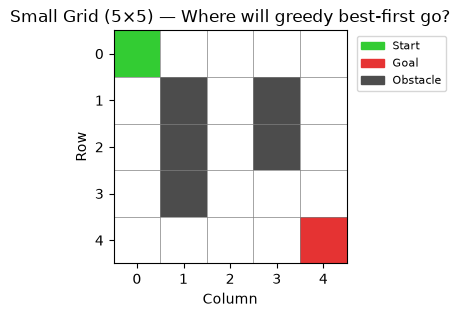

In [24]:
# Same small grid as P2
small_obstacles = {(1, 1), (2, 1), (3, 1), (1, 3), (2, 3)}
small_grid = GridWorld(5, 5, obstacles=small_obstacles)

small_grid.visualise(start=(0, 0), goal=(4, 4), title="Small Grid (5×5) — Where will greedy best-first go?")

Path found! Length: 9 steps
Path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
Nodes expanded: 18
Total cells explored: 20


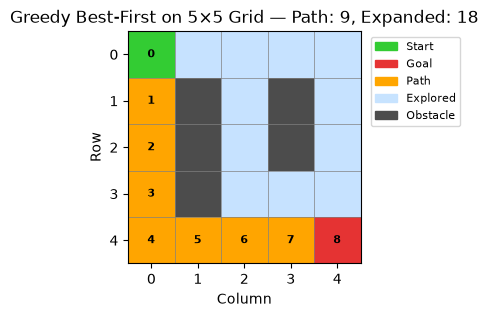

In [25]:
start = (0, 0)
goal = (4, 4)

path, explored, nodes_expanded = greedy_best_first_search(
    small_grid, start, goal, manhattan_distance
)

if path:
    print(f"Path found! Length: {len(path)} steps")
    print(f"Path: {path}")
    print(f"Nodes expanded: {nodes_expanded}")
    print(f"Total cells explored: {len(explored)}")
    small_grid.visualise(path=path, explored=explored, start=start, goal=goal,
                         title=f"Greedy Best-First on 5×5 Grid — Path: {len(path)}, Expanded: {nodes_expanded}")
else:
    print("No path found! Check your implementation.")

**Compare with P2.** Look at the light blue (explored) cells. In BFS, they spread out evenly in all directions. In greedy best-first, they should cluster toward the goal. That's the heuristic at work: the algorithm has a *sense of direction*.

---

## Part 5: Run on the large grid (10×10)

Now test on the same large grid from P2. Look at the obstacles: there are some narrow corridors. Will the heuristic lead the algorithm through them efficiently, or will it get drawn toward the goal and hit a wall?

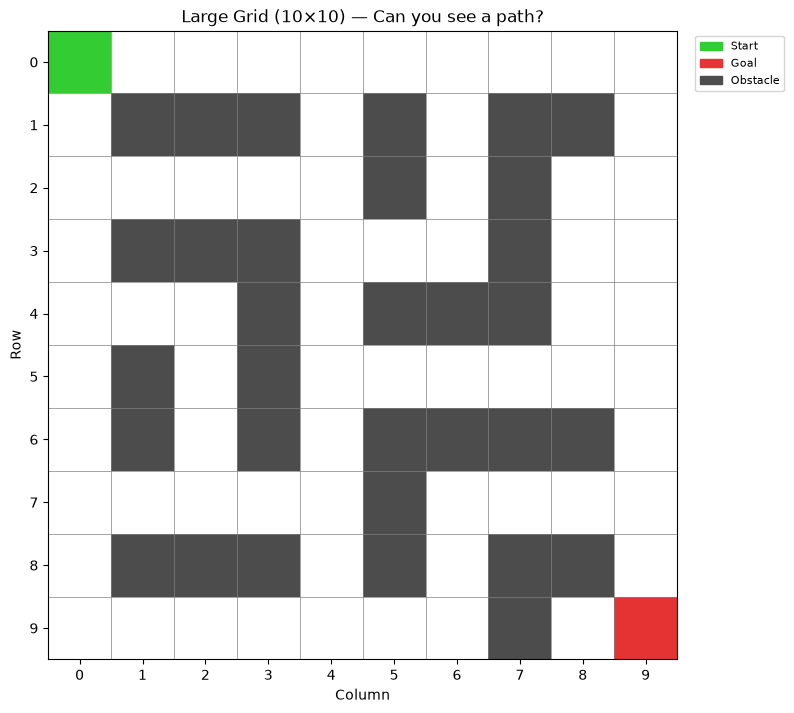

In [26]:
# Same large grid as P2
large_obstacles = {
    (1, 1), (1, 2), (1, 3), (1, 5), (1, 7), (1, 8),
    (2, 5), (2, 7),
    (3, 1), (3, 2), (3, 3), (3, 7),
    (4, 3), (4, 5), (4, 6), (4, 7),
    (5, 1), (5, 3),
    (6, 1), (6, 3), (6, 5), (6, 6), (6, 7), (6, 8),
    (7, 5),
    (8, 1), (8, 2), (8, 3), (8, 5), (8, 7), (8, 8),
    (9, 7),
}
large_grid = GridWorld(10, 10, obstacles=large_obstacles)

large_grid.visualise(start=(0, 0), goal=(9, 9), title="Large Grid (10×10) — Can you see a path?")

Path found! Length: 19 steps
Nodes expanded: 64
Total cells explored: 67
Grid size: 100 cells (32 obstacles)


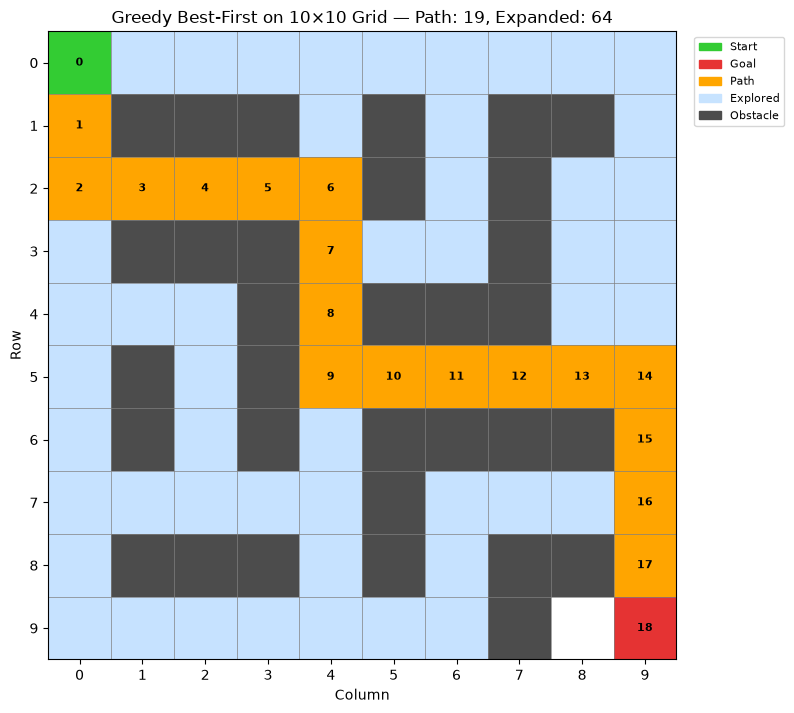

In [27]:
start = (0, 0)
goal = (9, 9)

path, explored, nodes_expanded = greedy_best_first_search(
    large_grid, start, goal, manhattan_distance
)

if path:
    print(f"Path found! Length: {len(path)} steps")
    print(f"Nodes expanded: {nodes_expanded}")
    print(f"Total cells explored: {len(explored)}")
    print(f"Grid size: {large_grid.rows * large_grid.cols} cells ({len(large_obstacles)} obstacles)")
    large_grid.visualise(path=path, explored=explored, start=start, goal=goal,
                         title=f"Greedy Best-First on 10×10 Grid — Path: {len(path)}, Expanded: {nodes_expanded}")
else:
    print("No path found!")

---

## Part 6: Compare BFS vs Greedy Best-First

Now let's bring in your BFS from P2 to compare directly. The BFS implementation below is the same one you wrote; run it to get the comparison numbers.

In [28]:
def bfs_search(grid_world, start, goal):
    """BFS from P2 — provided for comparison."""
    frontier = Queue()
    frontier.enqueue(start)
    came_from = {start: None}
    nodes_expanded = 0

    while not frontier.is_empty():
        current = frontier.dequeue()
        nodes_expanded += 1

        if current == goal:
            break

        row, col = current
        for neighbour in grid_world.get_neighbours(row, col):
            if neighbour not in came_from:
                frontier.enqueue(neighbour)
                came_from[neighbour] = current

    path = reconstruct_path(came_from, start, goal)
    explored = set(came_from.keys())
    return path, explored, nodes_expanded


# Run BFS on both grids for comparison
bfs_path_small, bfs_explored_small, bfs_expanded_small = bfs_search(small_grid, (0, 0), (4, 4))
bfs_path_large, bfs_explored_large, bfs_expanded_large = bfs_search(large_grid, (0, 0), (9, 9))

# Run greedy best-first on both grids
gbfs_path_small, gbfs_explored_small, gbfs_expanded_small = greedy_best_first_search(
    small_grid, (0, 0), (4, 4), manhattan_distance
)
gbfs_path_large, gbfs_explored_large, gbfs_expanded_large = greedy_best_first_search(
    large_grid, (0, 0), (9, 9), manhattan_distance
)

print("Comparison: BFS vs Greedy Best-First")
print("=" * 55)
print(f"{'':30s} {'BFS':>10s} {'Greedy':>10s}")
print("-" * 55)
print(f"{'Path length (small grid)':30s} {len(bfs_path_small):>10d} {len(gbfs_path_small):>10d}")
print(f"{'Nodes expanded (small grid)':30s} {bfs_expanded_small:>10d} {gbfs_expanded_small:>10d}")
print(f"{'Path length (large grid)':30s} {len(bfs_path_large):>10d} {len(gbfs_path_large):>10d}")
print(f"{'Nodes expanded (large grid)':30s} {bfs_expanded_large:>10d} {gbfs_expanded_large:>10d}")

Comparison: BFS vs Greedy Best-First
                                      BFS     Greedy
-------------------------------------------------------
Path length (small grid)                9          9
Nodes expanded (small grid)            20         18
Path length (large grid)               19         19
Nodes expanded (large grid)            67         64


In [29]:
# Bonus: try Euclidean distance instead of Manhattan.
# You already implemented euclidean_distance — let's see if it changes the path.
euc_path, euc_explored, euc_expanded = greedy_best_first_search(
    large_grid, (0, 0), (9, 9), euclidean_distance
)

print(f"Large grid — Manhattan heuristic: path={len(gbfs_path_large)}, expanded={gbfs_expanded_large}")
print(f"Large grid — Euclidean heuristic: path={len(euc_path)}, expanded={euc_expanded}")

if len(euc_path) != len(gbfs_path_large) or euc_expanded != gbfs_expanded_large:
    print("\nDifferent heuristic → different behaviour! The choice of heuristic matters.")
else:
    print("\nSame result this time — but on other grids, the choice can matter.")

Large grid — Manhattan heuristic: path=19, expanded=64
Large grid — Euclidean heuristic: path=19, expanded=18

Different heuristic → different behaviour! The choice of heuristic matters.


### Record your results

Fill in the comparison table below (double-click this cell to edit).

| | BFS (P2) | Greedy Best-First (P3) |
|---|---|---|
| Path length (small grid) | _9__ | _9__ |
| Nodes expanded (small grid) | _20__ | _18__ |
| Path length (large grid) | _19__ | _19__ |
| Nodes expanded (large grid) | _67__ | _64__ |

**Answer these questions** (double-click to edit):

1. Did greedy best-first expand fewer nodes than BFS? On which grid was the difference larger?

   yes, the bigger gris is the difference larger

2. Did greedy best-first find the shortest path? If not, why not?

   NO, it will always goes to the lowest heuristic, that might be the longer route

3. What is the tradeoff between BFS and greedy best-first search?

   greedy best first search might not find the sortest route but it expanded lesser

---

## Part 7: Understanding greedy best-first search (quiz)

Run the quiz below to check your understanding before your milestone discussion.

In [30]:
from jupyterquiz import display_quiz

gbfs_quiz = [
    {
        "question": "What makes greedy best-first search 'greedy'?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "It always expands the node that <i>appears</i> closest to the goal, without considering the cost to reach that node.", "correct": True, "feedback": "Correct! 'Greedy' means it makes locally optimal choices — picking whatever looks best right now. It doesn't consider how much effort it took to get there."},
            {"answer": "It explores every node in the graph as fast as possible.", "correct": False, "feedback": "That's more like BFS. Greedy best-first is selective — it focuses on nodes that seem close to the goal."},
            {"answer": "It uses more memory than other algorithms.", "correct": False, "feedback": "'Greedy' refers to the decision strategy, not memory usage."},
            {"answer": "It always finds the shortest path by being aggressive.", "correct": False, "feedback": "Greedy best-first does NOT guarantee the shortest path. Its greediness can lead it astray."}
        ]
    },
    {
        "question": "Why doesn't greedy best-first search guarantee the shortest path?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Because the heuristic only <i>estimates</i> distance — it can be wrong, leading the algorithm down a longer path.", "correct": True, "feedback": "Correct! The heuristic is a guess. A node that looks close to the goal might actually require a long detour around obstacles."},
            {"answer": "Because it doesn't use a frontier.", "correct": False, "feedback": "It does use a frontier — a priority queue. The issue is how it prioritises, not whether it has a frontier."},
            {"answer": "Because it visits nodes in random order.", "correct": False, "feedback": "The order is deterministic — sorted by heuristic value, not random."},
            {"answer": "Because it only works on small graphs.", "correct": False, "feedback": "Graph size isn't the issue. The shortest-path problem comes from ignoring the cost already spent."}
        ]
    },
    {
        "question": "If you changed the data structure from PriorityQueue back to Queue (FIFO), what algorithm would you get?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "BFS — exactly what you implemented in P2.", "correct": True, "feedback": "Correct! BFS and greedy best-first have the same structure. The only difference is the frontier: Queue (FIFO) gives BFS, PriorityQueue (by heuristic) gives greedy best-first."},
            {"answer": "DFS — depth-first search.", "correct": False, "feedback": "DFS uses a Stack (LIFO), not a Queue (FIFO)."},
            {"answer": "A* search.", "correct": False, "feedback": "A* uses a priority queue where the priority is cost-so-far + heuristic. A plain Queue gives BFS."},
            {"answer": "A broken algorithm that doesn't work.", "correct": False, "feedback": "It works perfectly — it's just BFS! Same code, different data structure, different algorithm."}
        ]
    }
]

display_quiz(gbfs_quiz, shuffle_answers=True)

<IPython.core.display.Javascript object>

---

## Part 8: Reflection — "Can a machine discover?" (P3.4)

Write a short reflective response (150–250 words) to the question:

> *"Can a machine discover?"*

AlphaGo's Move 37 was called "beautiful" and "creative" by Go experts. It was a move no human had considered. Did AlphaGo *discover* something, or did it just *compute*? What does "discovery" mean when an algorithm finds it?

**Write your response in the cell below — it stays in this notebook.** You do not upload it as a separate file.

**P3.4 reflection — your response (150–250 words):**

*(Write your reflection here. Double-click this cell to edit. It stays in the notebook — do not upload it separately.)*
For the algorithm, move 37 is just the largest possibility on the table, but for humans, the step people decide to take is based on experience. So i don't think this "discovery "means anything when understanding the decision that the algorithm makes. If you only consider finding new things to "discover", then algorithms or AI will be very helpful to help us find the one human missed. By using a like-for-or-while loop, it can check every potential result. 

Those who think AI is a miracle have very little understanding of AI. Even though we might not know the reasoning inside training a model, basic knowledge of AI, helps us differentiate some gossip with current hype. So, this class is important that we get a chance to learn more about AI, how it was made and the history of AI evolution. Even beside AI, the algorithm is very important. 

---

## Submission checklist

- [x ] P3.1: Hand trace of greedy best-first search on the 7-node graph (photographed)
- [x ] P3.2: Distance functions passing all unit tests (Part 2)
- [x ] P3.3: Greedy best-first search working on both grids (Parts 4–5)
- [x ] Comparison table filled in with BFS vs greedy best-first (Part 6)
- [x ] Reflection questions answered (Part 6)
- [x ] P3.4: Reflection on "Can a machine discover?" (150–250 words, written in Part 8 of this notebook)
- [x ] Milestone discussion booked with tutor

**Uploading to OnTrack.** Submit **two things**: (1) this completed notebook, and (2) a **single** photo or PDF of your hand trace (P3.1). Your P3.4 reflection stays *inside this notebook* — OnTrack allows only one extra file besides the notebook, and that file is your hand trace.